In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator , GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    include_gisd        = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    
# data_orchestrator = DataOrchestrator(config).build()


data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )



KeyboardInterrupt: 

In [ ]:
dataorchestrator    = (DataOrchestrator(config).build())
shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdataloader_gr1  = GraphDataLoaderManager(dataorchestrator).retrieve_static_graph('gravity1').construct_dataloaders()
graphdataloader_gr2  = GraphDataLoaderManager(dataorchestrator).retrieve_static_graph('gravity2').construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23029856/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(



==                   gcn_-_id                   ==
model_hparams_set ✓
global_hparams_set ✓
Epoch 1 train loss: 0.1492, val loss: 0.0921 ✓ (new best)
lr has been updated from 1.00e-04 to 5.00e-05
Early stopping: Validation loss hasn't improved for 7 epochs
Restored model from best validation loss: 0.0890
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 617.13it/s]


additonal transformation
forecasted ✓

==                   gcn_-_bn                   ==
model_hparams_set ✓
global_hparams_set ✓
Epoch 1 train loss: 0.1776, val loss: 0.1089 ✓ (new best)


KeyboardInterrupt: 

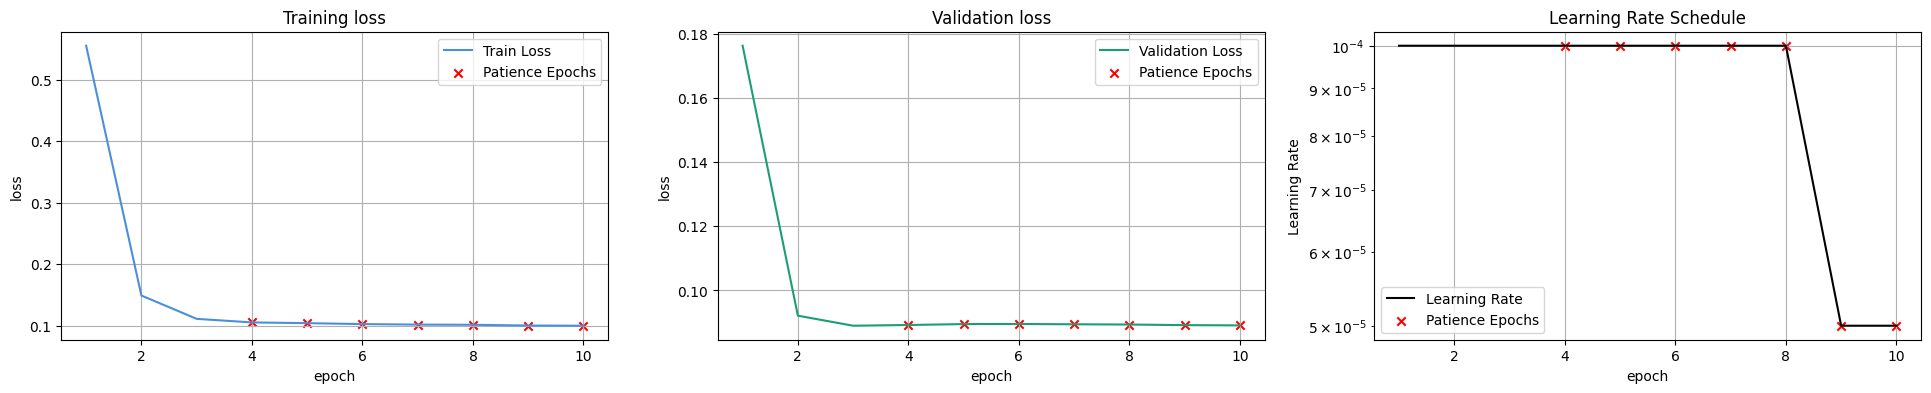

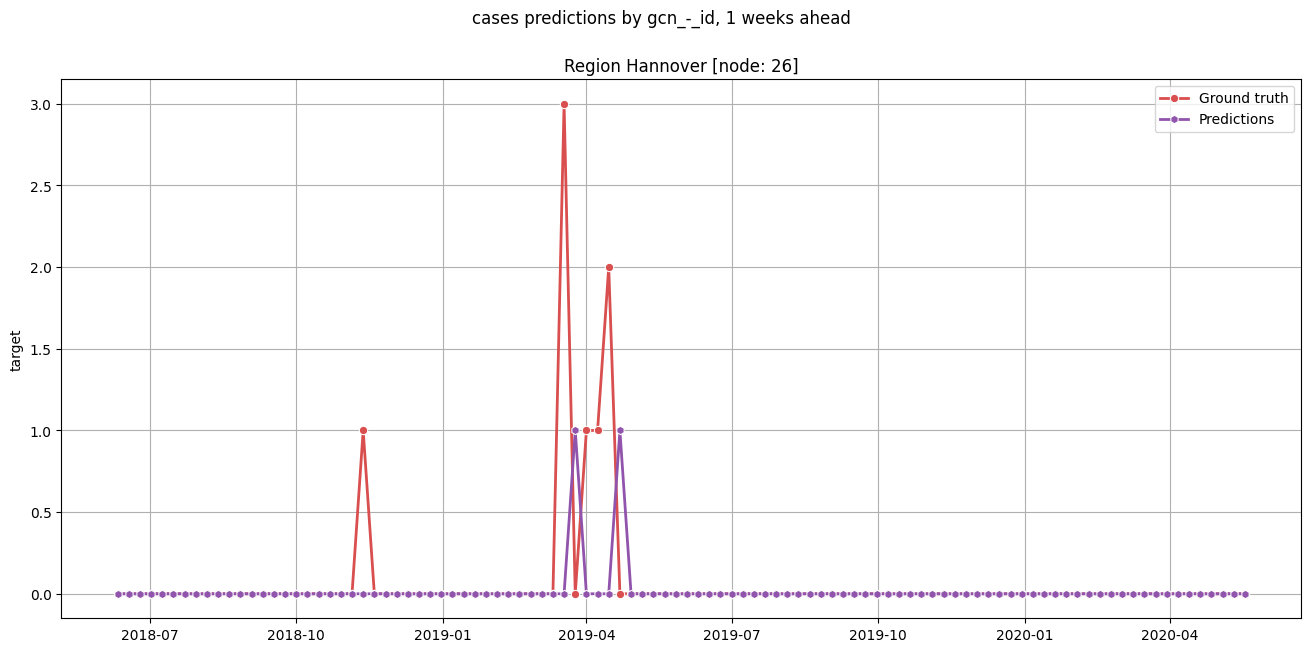

In [ ]:
from src.models import SpatialGNNModel

n_epochs        = 10
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 4},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 7,
    }

gcn1 = SpatialGNNModel(graphdataloader_id, name = 'gcn - id', verbose = 1)
gcn1.set_model_hparams()
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
f1 = gcn1.show_forecasts(26)

gcn2 = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn', verbose = 1)
gcn2.set_model_hparams()
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
f2 = gcn2.show_forecasts(26)

gcn3 = SpatialGNNModel(graphdataloader_gr1, name = 'gcn - gr1', verbose = 1)
gcn3.set_model_hparams()
gcn3.set_global_hparams(**global_hparams)
gcn3.train()
gcn3.forecast('test')
f3 = gcn3.show_forecasts(26)

gcn4 = SpatialGNNModel(graphdataloader_gr2, name = 'gcn - gr2', verbose = 1)
gcn4.set_model_hparams()
gcn4.set_global_hparams(**global_hparams)
gcn4.train()
gcn4.forecast('test')
f4 = gcn4.show_forecasts(26)

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'München [node: 223]'}, ylabel='target'>])

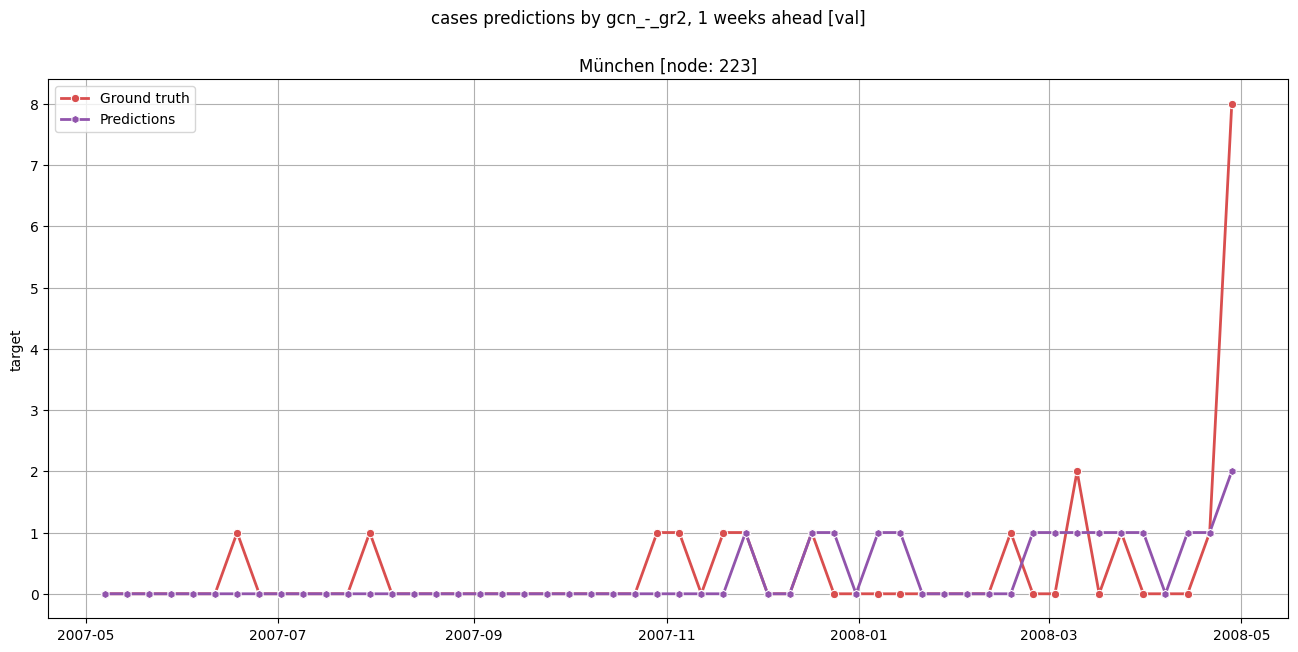

In [ ]:
gcn4.show_forecasts(223,'val')

In [ ]:
from src.evaluation import Evaluator

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  4.65it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


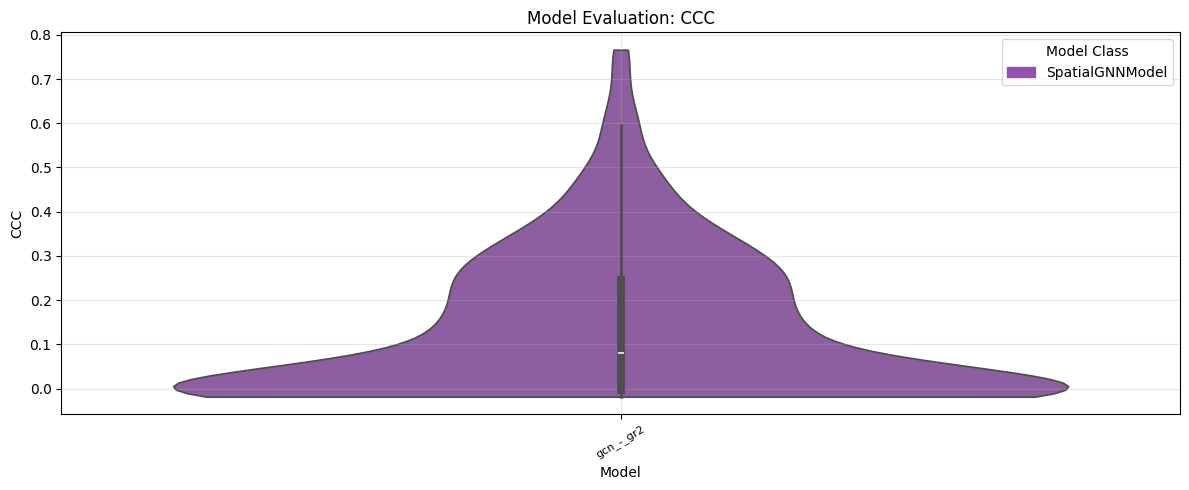

In [ ]:
e = Evaluator([gcn4])
e.add_evaluation(0,'train')
e.add_evaluation(0,'val')
e.add_evaluation(0,'test')
e.plotter.plot_metric('ccc','horizon_0','train')

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


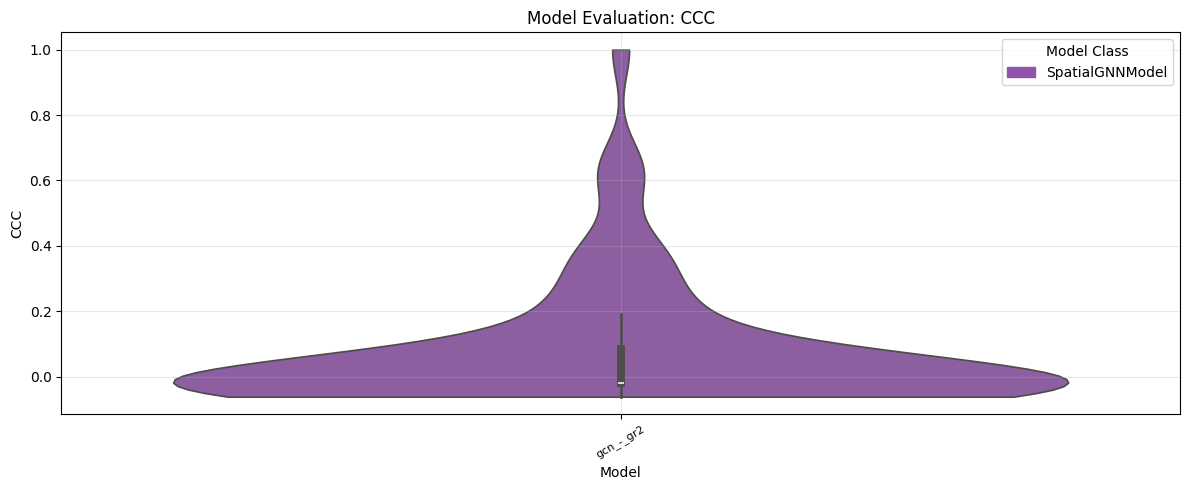

In [ ]:
e.plotter.plot_metric('ccc','horizon_0','val')

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


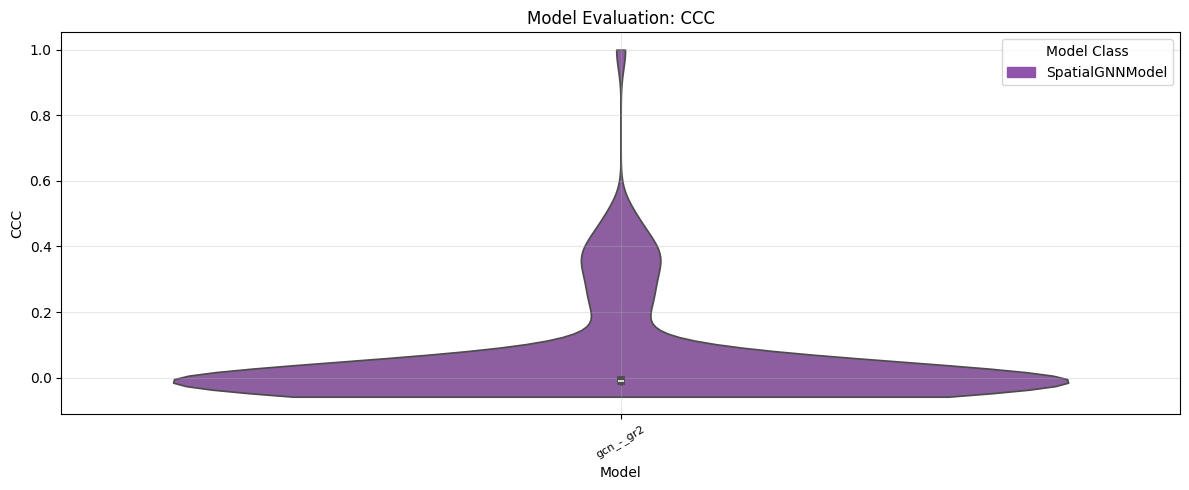

In [ ]:
e.plotter.plot_metric('ccc','horizon_0','test')


==                   gat_-_id                   ==
model_hparams_set ✓
global_hparams_set ✓
Epoch 1 train loss: 0.0917, val loss: 0.0874 ✓ (new best)
Epoch 11 train loss: 0.0667, val loss: 0.0772 (patience: 1/7)
Epoch 21 train loss: 0.0602, val loss: 0.0730 (patience: 2/7)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 31 train loss: 0.0573, val loss: 0.0715 (patience: 2/7)
Epoch 41 train loss: 0.0554, val loss: 0.0705 ✓ (new best)
lr has been updated from 5.00e-05 to 2.50e-05
Early stopping: Validation loss hasn't improved for 7 epochs
Restored model from best validation loss: 0.0704
trained ✓


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:01<00:00, 86.88it/s]


additonal transformation
forecasted ✓

==                   gat_-_bn                   ==
model_hparams_set ✓
global_hparams_set ✓
Epoch 1 train loss: 0.1277, val loss: 0.1021 ✓ (new best)
Epoch 11 train loss: 0.0878, val loss: 0.0882 ✓ (new best)
Epoch 21 train loss: 0.0802, val loss: 0.0848 (patience: 1/7)
Epoch 31 train loss: 0.0738, val loss: 0.0828 ✓ (new best)
Epoch 41 train loss: 0.0695, val loss: 0.0805 ✓ (new best)
Epoch 51 train loss: 0.0641, val loss: 0.0775 ✓ (new best)
Epoch 61 train loss: 0.0637, val loss: 0.0764 (patience: 4/7)
Epoch 71 train loss: 0.0593, val loss: 0.0760 (patience: 2/7)
Early stopping: Validation loss hasn't improved for 7 epochs
Restored model from best validation loss: 0.0758
trained ✓


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:01<00:00, 76.38it/s]


additonal transformation
forecasted ✓

==                  gat_-_gr1                   ==
model_hparams_set ✓
global_hparams_set ✓
Epoch 1 train loss: 0.1017, val loss: 0.0889 ✓ (new best)
Epoch 11 train loss: 0.0833, val loss: 0.0821 (patience: 1/7)
Epoch 21 train loss: 0.0810, val loss: 0.0794 ✓ (new best)
Epoch 31 train loss: 0.0784, val loss: 0.0782 (patience: 2/7)
Epoch 41 train loss: 0.0775, val loss: 0.0764 (patience: 1/7)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 51 train loss: 0.0749, val loss: 0.0758 (patience: 2/7)
lr has been updated from 5.00e-05 to 2.50e-05
Early stopping: Validation loss hasn't improved for 7 epochs
Restored model from best validation loss: 0.0757
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 170.07it/s]


additonal transformation
forecasted ✓

==                  gat_-_gr2                   ==
model_hparams_set ✓
global_hparams_set ✓
Epoch 1 train loss: 0.1235, val loss: 0.0980 ✓ (new best)
Epoch 11 train loss: 0.0977, val loss: 0.0880 ✓ (new best)
lr has been updated from 1.00e-04 to 5.00e-05
Early stopping: Validation loss hasn't improved for 7 epochs
Restored model from best validation loss: 0.0862
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 212.40it/s]


additonal transformation
forecasted ✓


GATv2Model(name='gat_-_gr2')

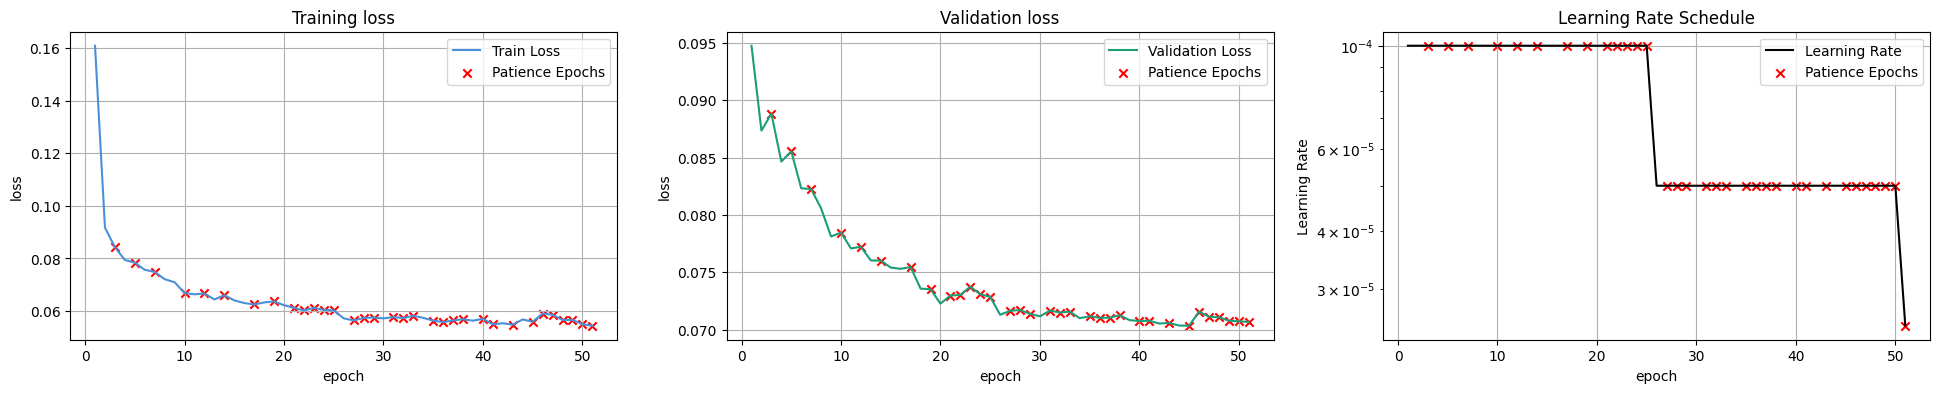

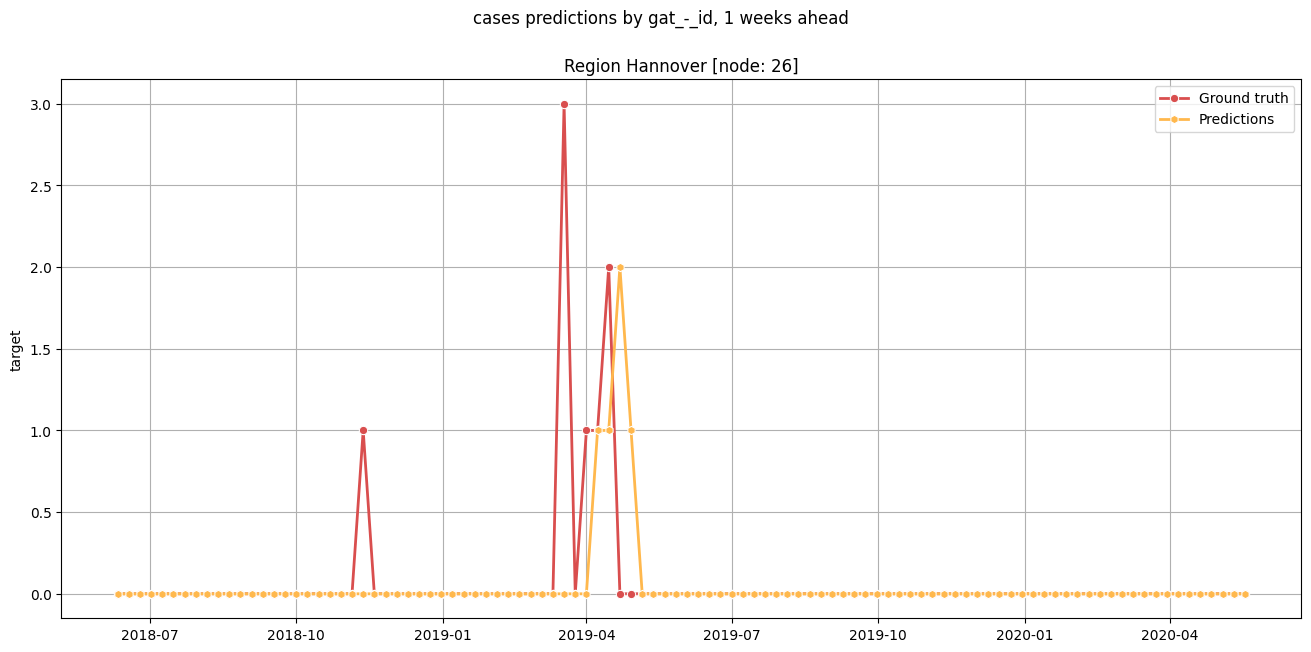

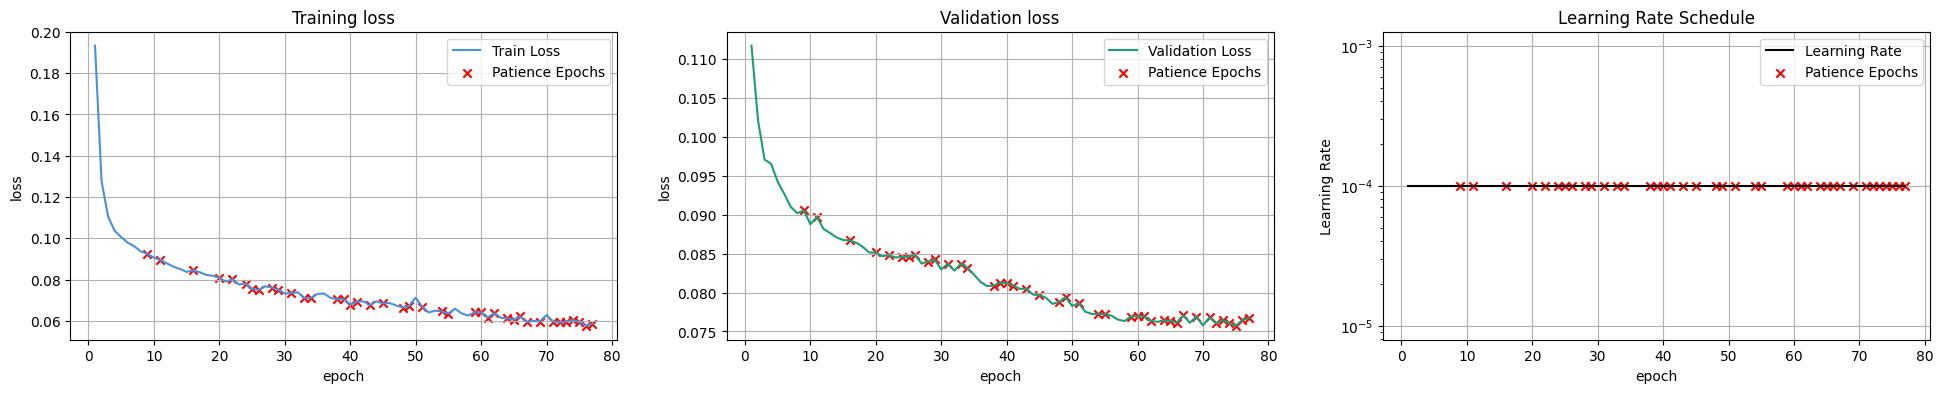

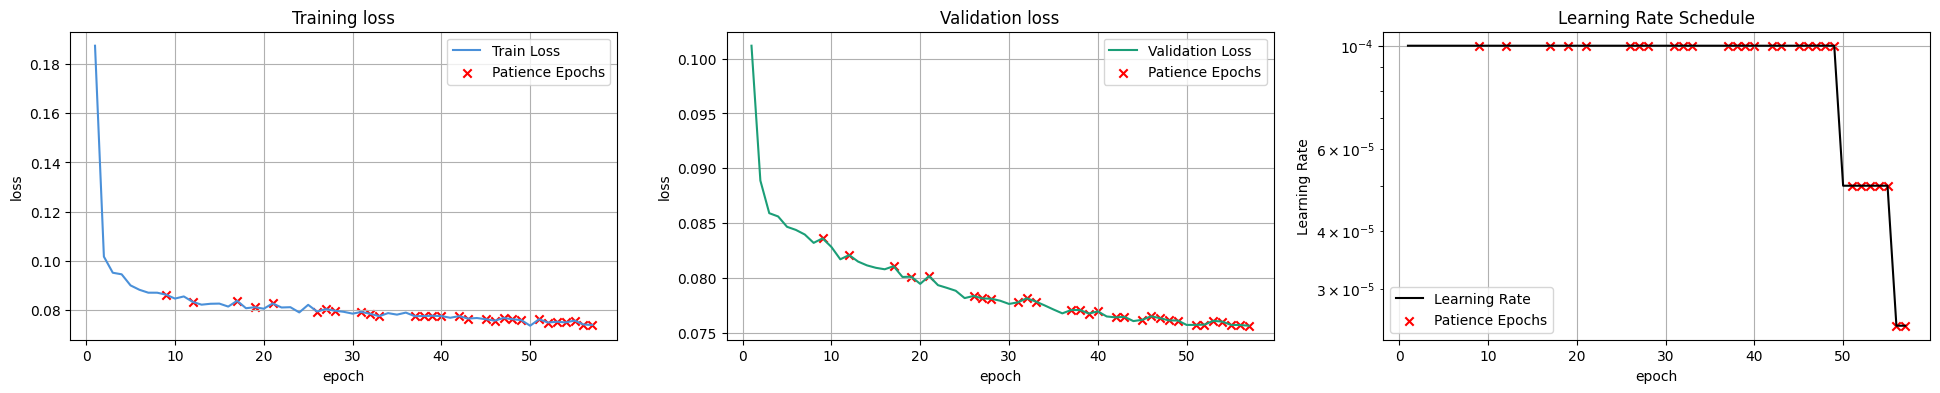

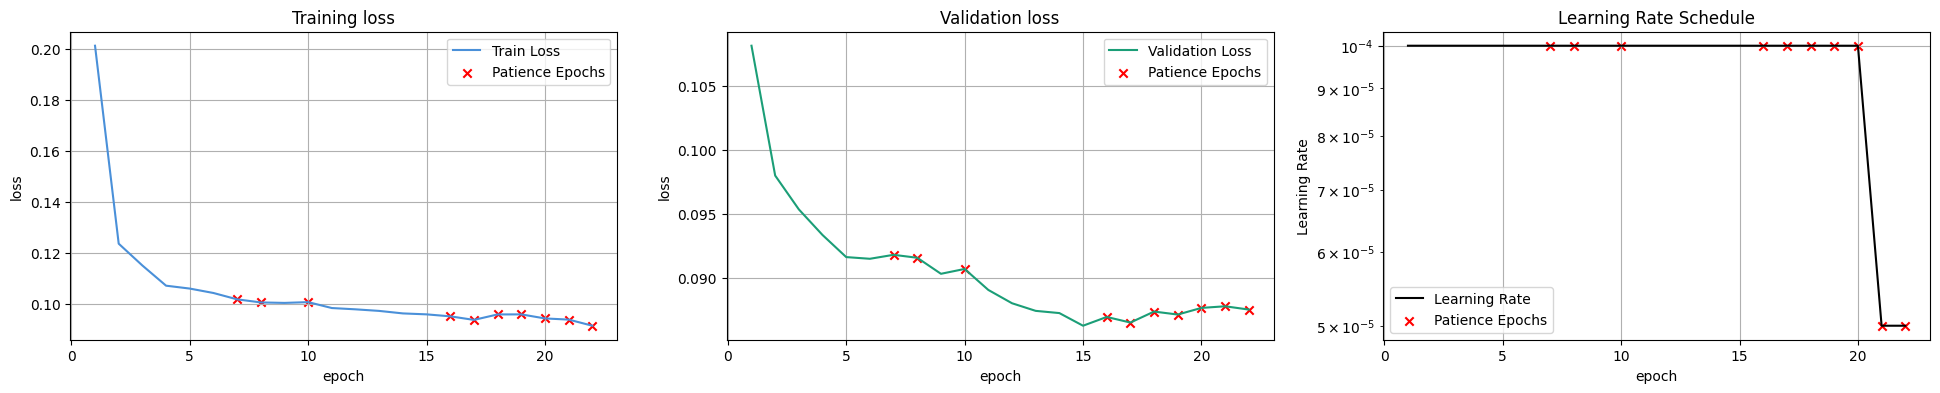

In [ ]:
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 4},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 7,
    }

gat1 = GATv2Model(graphdataloader_id, name = 'gat - id', verbose = 1)
gat1.set_model_hparams()
gat1.set_global_hparams(**global_hparams)
gat1.train()
gat1.forecast('test')
gat1.show_forecasts(26)

gat2 = GATv2Model(graphdataloader_bn, name = 'gat - bn', verbose = 1)
gat2.set_model_hparams()
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
# gcn.show_forecasts(26)

gat3 = GATv2Model(graphdataloader_gr1, name = 'gat - gr1', verbose = 1)
gat3.set_model_hparams()
gat3.set_global_hparams(**global_hparams)
gat3.train()
gat3.forecast('test')
# gcn.show_forecasts(26)

gat4 = GATv2Model(graphdataloader_gr2, name = 'gat - gr2', verbose = 1)
gat4.set_model_hparams()
gat4.set_global_hparams(**global_hparams)
gat4.train()
gat4.forecast('test')
# gcn.show_forecasts(26)

Overall Metrics:
  Sensitivity/Recall: 0.218 (caught 21.8% of outbreak weeks)
  Precision: 0.261 (26.1% of predictions were correct)
  F1-Score: 0.237

Confusion Matrix:
  True Negatives (correctly predicted no outbreak): 39954
  False Positives (false alarms): 322
  False Negatives (MISSED outbreaks): 410
  True Positives (caught outbreaks): 114

⚠️  LAG DIAGNOSTIC:
  Total actual outbreak weeks: 524
  Total predicted outbreak weeks: 436
  Difference: -88
  FP/FN ratio: 0.79


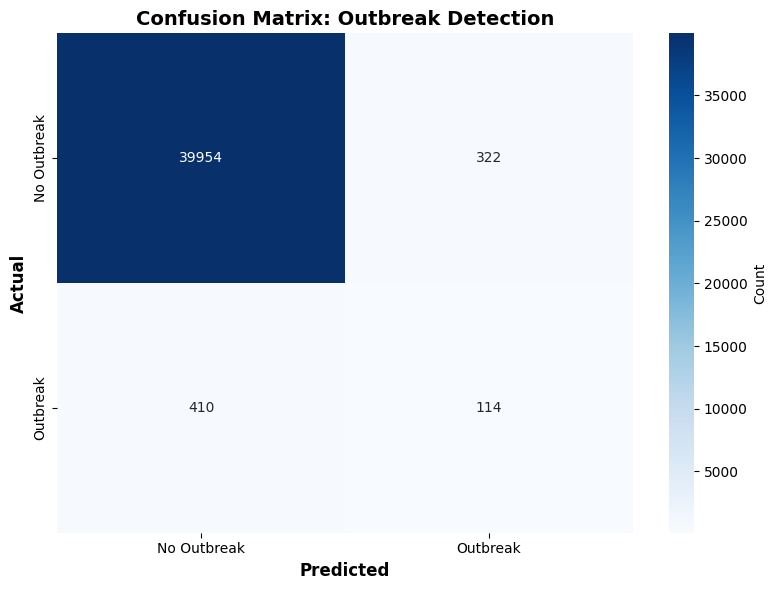


Municipalities with outbreaks: 189
Average sensitivity (for municipalities with cases): 0.094


,weeks_with_cases,weeks_predicted_cases,true_positives,false_negatives,false_positives,sensitivity
node,,,,,,
0,1,1,0,1,1,0.0
1,0,0,0,0,0,NaN
2,1,1,0,1,1,0.0
3,0,0,0,0,0,NaN
4,1,0,0,1,0,0.0
...,...,...,...,...,...,...
395,0,0,0,0,0,NaN
396,0,0,0,0,0,NaN
397,0,0,0,0,0,NaN


In [ ]:
evaluate_model_binarily(gcn1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

def evaluate_model_binarily(model):
    predictions_copys = model.predictions.test.get_original(0).copy()
    df = predictions_copys

    # Create binary versions
    df['target_binary'] = (df['target'] > 0).astype(int)
    df['pred_binary'] = (df['pred'] > 0).astype(int)

    # Overall metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        df['target_binary'], 
        df['pred_binary'],
        average='binary',
        zero_division=0
    )

    print(f"Overall Metrics:")
    print(f"  Sensitivity/Recall: {recall:.3f} (caught {recall*100:.1f}% of outbreak weeks)")
    print(f"  Precision: {precision:.3f} ({precision*100:.1f}% of predictions were correct)")
    print(f"  F1-Score: {f1:.3f}")

    # Confusion matrix
    cm = confusion_matrix(df['target_binary'], df['pred_binary'])
    tn, fp, fn, tp = cm.ravel()

    print(f"\nConfusion Matrix:")
    print(f"  True Negatives (correctly predicted no outbreak): {tn}")
    print(f"  False Positives (false alarms): {fp}")
    print(f"  False Negatives (MISSED outbreaks): {fn}")
    print(f"  True Positives (caught outbreaks): {tp}")

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Outbreak', 'Outbreak'],
                yticklabels=['No Outbreak', 'Outbreak'],
                cbar_kws={'label': 'Count'},
                ax=ax)
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix: Outbreak Detection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Per-municipality summary
    municipality_metrics = df.groupby('node', group_keys=False).apply(
        lambda x: pd.Series({
            'weeks_with_cases': (x['target'] > 0).sum(),
            'weeks_predicted_cases': (x['pred'] > 0).sum(),
            'true_positives': ((x['target'] > 0) & (x['pred'] > 0)).sum(),
            'false_negatives': ((x['target'] > 0) & (x['pred'] == 0)).sum(),
            'false_positives': ((x['target'] == 0) & (x['pred'] > 0)).sum(),
        }), include_groups=False  # This fixes the deprecation warning
    )

    municipality_metrics['sensitivity'] = (
        municipality_metrics['true_positives'] / 
        municipality_metrics['weeks_with_cases'].replace(0, np.nan)
    )

    print(f"\nMunicipalities with outbreaks: {(municipality_metrics['weeks_with_cases'] > 0).sum()}")
    print(f"Average sensitivity (for municipalities with cases): {municipality_metrics['sensitivity'].mean():.3f}")
    
    return municipality_metrics

In [ ]:
def evaluate_model_binarily(model):
    predictions_copys = model.predictions.test.get_original(0).copy()
    df = predictions_copys

    # Create binary versions
    df['target_binary'] = (df['target'] > 0).astype(int)
    df['pred_binary'] = (df['pred'] > 0).astype(int)

    # Overall metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        df['target_binary'], 
        df['pred_binary'],
        average='binary',
        zero_division=0
    )

    print(f"Overall Metrics:")
    print(f"  Sensitivity/Recall: {recall:.3f} (caught {recall*100:.1f}% of outbreak weeks)")
    print(f"  Precision: {precision:.3f} ({precision*100:.1f}% of predictions were correct)")
    print(f"  F1-Score: {f1:.3f}")

    # Confusion matrix
    cm = confusion_matrix(df['target_binary'], df['pred_binary'])
    tn, fp, fn, tp = cm.ravel()

    print(f"\nConfusion Matrix:")
    print(f"  True Negatives (correctly predicted no outbreak): {tn}")
    print(f"  False Positives (false alarms): {fp}")
    print(f"  False Negatives (MISSED outbreaks): {fn}")
    print(f"  True Positives (caught outbreaks): {tp}")
    
    # **LAG DETECTION**
    total_actual_outbreaks = tp + fn
    total_predicted_outbreaks = tp + fp
    lag_ratio = fp / fn if fn > 0 else np.inf
    
    print(f"\n⚠️  LAG DIAGNOSTIC:")
    print(f"  Total actual outbreak weeks: {total_actual_outbreaks}")
    print(f"  Total predicted outbreak weeks: {total_predicted_outbreaks}")
    print(f"  Difference: {total_predicted_outbreaks - total_actual_outbreaks}")
    print(f"  FP/FN ratio: {lag_ratio:.2f}")
    
    if abs(total_predicted_outbreaks - total_actual_outbreaks) < 10 and abs(fp - fn) < 10:
        print(f"  ⚠️  WARNING: Model shows PERFECT LAG signature!")
        print(f"     → Likely just echoing past observations (persistence)")
        print(f"     → Not providing genuine forecasting value")

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Outbreak', 'Outbreak'],
                yticklabels=['No Outbreak', 'Outbreak'],
                cbar_kws={'label': 'Count'},
                ax=ax)
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix: Outbreak Detection', fontsize=14, fontweight='bold')
    
    # Add lag warning to plot if detected
    if abs(total_predicted_outbreaks - total_actual_outbreaks) < 10 and abs(fp - fn) < 10:
        ax.text(0.5, -0.15, '⚠️ WARNING: Persistence/Lag Pattern Detected', 
                transform=ax.transAxes, ha='center', color='red', 
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

    # Per-municipality summary
    municipality_metrics = df.groupby('node', group_keys=False).apply(
        lambda x: pd.Series({
            'weeks_with_cases': (x['target'] > 0).sum(),
            'weeks_predicted_cases': (x['pred'] > 0).sum(),
            'true_positives': ((x['target'] > 0) & (x['pred'] > 0)).sum(),
            'false_negatives': ((x['target'] > 0) & (x['pred'] == 0)).sum(),
            'false_positives': ((x['target'] == 0) & (x['pred'] > 0)).sum(),
        }), include_groups=False
    )

    municipality_metrics['sensitivity'] = (
        municipality_metrics['true_positives'] / 
        municipality_metrics['weeks_with_cases'].replace(0, np.nan)
    )

    print(f"\nMunicipalities with outbreaks: {(municipality_metrics['weeks_with_cases'] > 0).sum()}")
    print(f"Average sensitivity (for municipalities with cases): {municipality_metrics['sensitivity'].mean():.3f}")
    
    return municipality_metrics